# Methodology

## General

### Data source & pre-processing

Data for this study was from the Met Service Fire Weather Index dataset, which holds fire weather index predictions based on weather model data from 2001 through 2019. Data was collected by the New Zealand Meteorological Service and accessed via University of Canterbury's GSDS department server in September 2026.

Only data for the months of December, January, February and March were included in the analysis. The rest of the year is considered low risk for fires in New Zealand and was therefore excluded.

Land pixels are scaled into a normalised feature space for building the self-organising map, to enable fair distance calculations during training.

### Methodology

#### Question 1: What areas in New Zealand have been experiencing extreme FWI conditions over the last 20 years?

A 5x5 grid self-organisation map (SOM) was built to cluster fire weather patterns into discrete states. Hyperparameters were chosen by executing a parameter search over various values of sigma (neighbourhood size) and learning rate. Selection of hyperparameters from this search was driven by quantisation error, topographic error, and U-Matrix.

The national benchmark value of FWI was calculated as the 95th percentile limit across all land pixels and all summer month data points. For each SOM node a 95th percentil map was contsructed. Node 24 was selected as the most extreme node as it contained the largest number of locations exceeding the 95th percentile threshold.

#### Question 2: Which months in the defined fire season are we usually experiencing more extreme FWI conditions over the last 20 years?

To evaluate temporal frequency of extreme FWI days, the data points assigned to the most extreme SOM node (node 24) were extracted and counted per month. The per-month values were plotted on histograms with the national 95th percentile threshold overlaid.

#### Question 3: Is Canterbury experiencing an increasing trend of extreme FWI days over the last 20 years?

The township of Darfield was selected as a representative location for Canterbury. To evaluate if there was any trend to the occurence of extreme FWI days, the baseline unclustered FWI values for this location and the extreme node values for this location were both evaluated with a Mann-Kendall test and the results plotted. The Mann-Kendall test identifies trends by comparing each data point with all subsequent data points in chronological order. Increases and decreases in values are accumulated, which can assign an overall postive or negative trend. After accounting for sample size and converting to a z-score the final result can indicate whether a trend exists and whether it is statistically significant.

Sen's slope was also plotted over the Mann-Kendall plots. This slope represents the true linear rate of change of a time series by calculating the median of all pairs of slopes between data points.

# What areas in New Zealand have been experiencing extreme FWI conditions over the last 20 years?

## Code and results

In [1]:
# Import required libraries

import os
from glob import glob
from time import time
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from minisom import MiniSom
import pymannkendall as mk
import pandas as pd

In [2]:
# Define constants that are used throughout the notebook
NZ_EXTENT=(165, 180, -48.8, -33.5)
SUMMER_MONTHS = [12, 1, 2, 3 ]
MONTH_NAMES = ["Dec", "Jan", "Feb", "Mar"]

# Darfield location
DARFIELD_LAT = -43.48
DARFIELD_LON = 172.11

In [3]:
# Load the data files

# Path to the main folder containing the subfolders with the FWI .nc files
main_folder = "/mnt/data/MetService_FWI"

# Recursively find all .nc files in subfolders
nc_files = glob(os.path.join(main_folder, "**", "*.nc"), recursive=True)

In [4]:
# Open and combine all netCDF files into one dataset
full_dataset = xr.open_mfdataset(
    nc_files,
    combine="by_coords",
    chunks='auto',
)

#### Utility functions

The below utility functions were adapted from fwi_som_helper.py

In [5]:
def min_max_scaling(data):
    # Calculate the minimum and maximum values for each feature
    min_vals = data.min()
    max_vals = data.max()
    
    # Perform min-max scaling
    scaled_data = (data - min_vals) / (max_vals - min_vals)
    return scaled_data

def preprocess(data_array):
    # Stack lat/lon -> "space" dimension
    X = data_array.stack(space=('lat','lon')).transpose('time', 'space')

    # Drop grid cells (space) that are all-NaN across time
    X = X.dropna(dim='space', how='all')

    # Fill remaining NaNs with 0 (simple demo choice)
    X = X.fillna(0.0)

    # Scale the data
    preprocessed = min_max_scaling(X)
    return X, preprocessed

def som_distance_map(ax, som, training_data, title):
    u = som.distance_map()
    mappable = ax.imshow(u, origin='upper', cmap='bone_r')
    ax.set_title(title, fontsize=8)
    ax.set_xlabel('j (x-axis of SOM grid)')
    ax.set_ylabel('i (y-axis of SOM grid)')
    ar = som.activation_response(training_data)
    for x in range(ar.shape[0]):
        for y in range(ar.shape[1]):
            freq = ar[x, y]
            if freq > 0:
                ax.plot(x, y, 'ro', markersize=np.sqrt(freq)*2, alpha=0.6)
    return mappable

def create_proto_maps(som, som_x, som_y, X_orig):
    """
    Convert MiniSom prototype weights from scaled feature space back into
    FWI units and reconstruct them as latitude-longitude maps.
    This assumes the SOM was trained using global min-max scaling:
        X_scaled = (X_orig - X_orig.min()) / (
            X_orig.max() - X_orig.min()
        )
    """
    n_units = som_x * som_y
    n_features = X_orig.sizes["space"]

    W_scaled = som.get_weights()
    expected_shape = (som_x, som_y, n_features)
    if W_scaled.shape != expected_shape:
        raise ValueError(f"Unexpected SOM weight shape {W_scaled.shape}. "f"Expected {expected_shape}.")

    # Flatten the SOM grid into a single unit dimension
    W_scaled = W_scaled.reshape(n_units, n_features)

    # Recover the global range used during min-max scaling
    minval = float(X_orig.min().compute())
    maxval = float(X_orig.max().compute())
    valrange = maxval - minval

    if not np.isfinite(valrange) or valrange <= 0:
        raise ValueError(f"Invalid FWI scaling range: min={minval}, max={maxval}")

    # Undo global min-max scaling
    W_original = W_scaled * valrange + minval

    # Attach the original stacked spatial coordinate
    proto_maps = xr.DataArray(
        W_original,
        coords={"unit": np.arange(n_units),"space": X_orig["space"],},
        dims=("unit", "space"),
        name="prototype",
        attrs={"long_name": "SOM prototype FWI","units": X_orig.attrs.get("units", ""),},
    )

    # Restore the 2D spatial grid and ensure coordinates are monotonic
    proto_maps = (
        proto_maps
        .unstack("space")
        .sortby("lat")
        .sortby("lon")
    )

    return proto_maps

def plot_som_maps(proto_maps,som_x,som_y,min_value=None,max_value=None,cmap="gist_rainbow"):
    required_dims = {"unit", "lat", "lon"}
    if not required_dims.issubset(proto_maps.dims):
        raise ValueError("proto_maps must contain the dimensions 'unit', 'lat', and 'lon'.")

    expected_units = som_x * som_y
    if proto_maps.sizes["unit"] != expected_units:
        raise ValueError(f"proto_maps contains {proto_maps.sizes['unit']} units, but som_x * som_y is {expected_units}.")

    # Ensure pcolormesh receives monotonically ordered coordinates
    proto_maps = (
        proto_maps
        .sortby("lat")
        .sortby("lon")
    )

    lat_increasing = np.all(np.diff(proto_maps["lat"].values) > 0)
    lon_increasing = np.all(np.diff(proto_maps["lon"].values) > 0)

    if not lat_increasing or not lon_increasing:
        raise ValueError("Latitude and longitude coordinates must be strictly increasing after sorting.")

    if min_value is None:
        min_value = float(proto_maps.min().compute())

    if max_value is None:
        max_value = float(proto_maps.max().compute())

    if min_value >= max_value:
        raise ValueError(f"min_value must be below max_value, got {min_value} and {max_value}.")

    fig, axes = plt.subplots(
        nrows=som_x,
        ncols=som_y,
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(12, 10),
    )
    axes = np.asarray(axes).reshape(som_x, som_y)
    im = None

    for i in range(som_x):
        for j in range(som_y):
            unit_id = i * som_y + j
            ax = axes[i, j]

            prototype = proto_maps.isel(unit=unit_id)

            im = ax.pcolormesh(
                prototype["lon"].values,
                prototype["lat"].values,
                prototype.values,
                transform=ccrs.PlateCarree(),
                shading="auto",
                cmap=cmap,
                vmin=min_value,
                vmax=max_value,
            )

            ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=60)
            ax.coastlines(linewidth=0.6, color="black", zorder=70 )
            ax.set_extent(NZ_EXTENT, crs=ccrs.PlateCarree())
            ax.set_title(f"Unit {unit_id} ({i},{j})",fontsize=10)

    cbar = fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        orientation="horizontal",
        fraction=0.05,
        pad=0.06,
    )
    cbar.set_label("FWI")
    plt.show()

In [6]:
# SUMMER_MONTHS: a constant value encapsulating month indices for December through March
summer_mask = full_dataset.time.dt.month.isin(SUMMER_MONTHS)

# Select the data for those months
full_dataset_summer_months = full_dataset.sel(time=summer_mask)

# Run through the preprocessing helper
original_data, preprocessed = preprocess(full_dataset_summer_months['FWI'])

#### Hyperparameter selection

To determine the best settings for training I performed the below hyperparameter search: iterating over several values of neighbourhood size (sigma) and learning rate and visualising results to help guide parameter selection. The U-Matrix includes red dots to indicate the activation response for each node: how many times that node has been selected as the best matching unit for the input data. 

Trained SOM: sigma=1.0, learning rate=0.01: QE=4.552765101306069, TE=0.24725943970767356.
Trained SOM: sigma=1.0, learning rate=0.05: QE=4.454342591032769, TE=0.15468940316686966.
Trained SOM: sigma=1.0, learning rate=0.1: QE=4.453595056883945, TE=0.1851400730816078.
Trained SOM: sigma=1.0, learning rate=0.5: QE=4.651866469197745, TE=0.583028826634186.


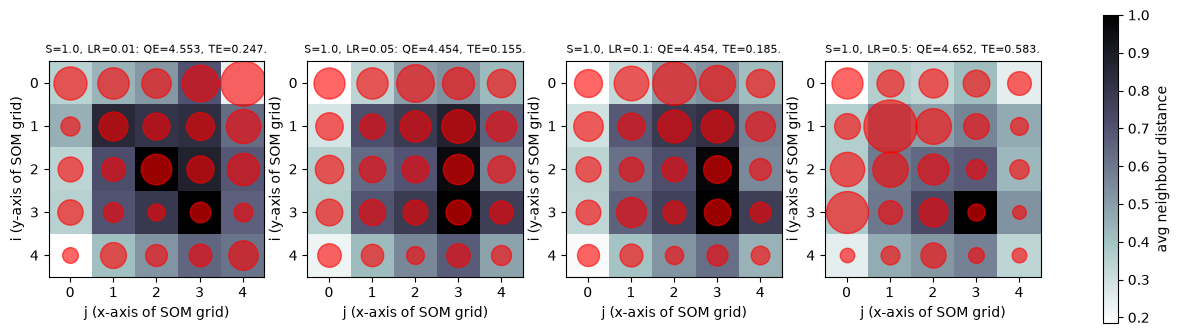

Trained SOM: sigma=2.0, learning rate=0.01: QE=4.6808028275432045, TE=0.02639058059277304.
Trained SOM: sigma=2.0, learning rate=0.05: QE=4.635240851059778, TE=0.015834348355663823.
Trained SOM: sigma=2.0, learning rate=0.1: QE=4.6345373165744626, TE=0.01908241981323589.
Trained SOM: sigma=2.0, learning rate=0.5: QE=4.703998793621063, TE=0.05278116118554608.


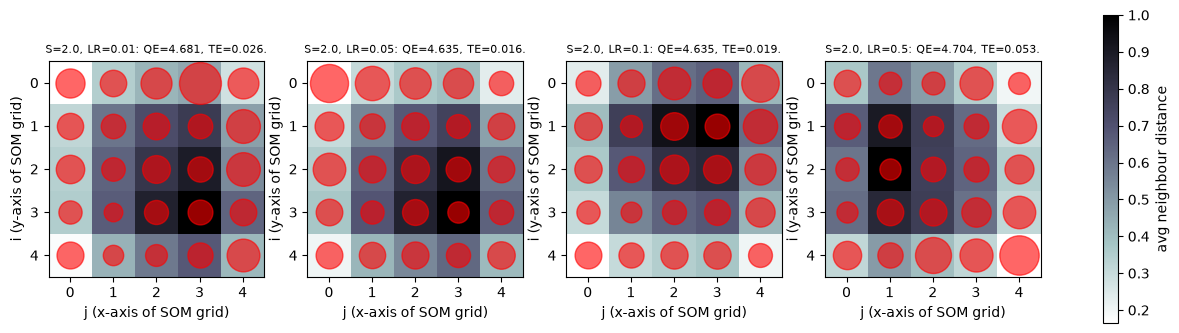

In [ ]:
# Constants
SOM_X = 5
SOM_Y = 5
NUM_ITERATIONS = 10000

results = {}
training_data = preprocessed.values

for x, sigma in enumerate([1.0, 2.0, 3.0]):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    results[sigma] = {}
    for y, lr in enumerate([0.01, 0.05, 0.1, 0.5]):
        som = MiniSom(
            x=SOM_X, y=SOM_Y,
            input_len=training_data.shape[1],
            sigma=sigma,
            learning_rate=lr,
            neighborhood_function='gaussian',
            random_seed=42
        )

        som.random_weights_init(training_data)
        som.train_random(training_data, num_iteration=NUM_ITERATIONS, verbose=False)
        qe = som.quantization_error(training_data)
        te = som.topographic_error(training_data)
        results[sigma][lr] = qe

        title = f"S={sigma}, LR={lr}: QE={qe:.3f}, TE={te:.3f}."
        print(f"Trained SOM: sigma={sigma}, learning rate={lr}: QE={qe}, TE={te}.")
        mappable = som_distance_map(axes[y], som, training_data, title)
        som = None

    fig.colorbar(mappable, ax=axes.ravel().tolist(), orientation='vertical', label='avg neighbour distance')
    plt.grid(False)
    plt.show()

To select a set of hyperparameters, I looked at some general qualities of the U-Matrix:
* Smooth gradients between the cells, so the cells look like they're arranged rather than randomly scattered in the matrix.
* Defined boundaries between dark and light areas.

In addition, the red dots indicate the frequency of values in each cluster. The largest dots ought to occur on the lightest cells, because those cells should be representing the 'standard' or most common data points. The smallest dots should occur on the dark cells, because those cells represent the most extreme values, which by definition should have a low frequency within the data.

As well as the above, I spot-checked some of the parameter combinations with a larger number of training iterations and with a smaller number of SOM grid cells. But found that 5x5 still provided the best error rate, and increasing the number of iterations did not lower the error rates.

Based on the hyperparameter search I settled on parameters `SIGMA=3`, `LEARNING_RATE=0.01`, `NUM_ITERATIONS=10000`.


#### Train the SOM

With the selected parameters we now train the SOM.

In [ ]:
# Constants
SOM_X = 5
SOM_Y = 5
NUM_ITERATIONS = 10000
SIGMA = 3.0
LEARNING_RATE = 0.1

som = MiniSom(
    x=SOM_X, y=SOM_Y,
    input_len=training_data.shape[1],
    sigma=SIGMA,
    learning_rate=LEARNING_RATE,
    random_seed=42
)
som.random_weights_init(training_data)
som.train_random(training_data, num_iteration=NUM_ITERATIONS, verbose=True)

qe = som.quantization_error(training_data)
te = som.topographic_error(training_data)

print(f"Trained SOM: {SOM_X}x{SOM_Y} sigma={SIGMA} learning rate={LEARNING_RATE} with {NUM_ITERATIONS} iterations. quantisation error={qe:.4f}, topographic error={te:.4f}")

#### Group the data into best matching units

In [ ]:
# For each value in preprocessed data, find the SOM node that it best goes in.
# One 'value' = an array of numbers. The numbers are FWI values without any
# lat/lon coordinate or time stamp, but at this point those coordinates don't
# matter because we're only figuring out the frequencies of values.
bmus = [som.winner(s) for s in preprocessed.values]

# Associate each BMU decision to the label of the node that was selected for it
labels = np.array([i * SOM_Y + j for (i, j) in bmus])

# Turn this into a data array
som_labels = xr.DataArray(
    labels,
    coords={'time': preprocessed['time']},
    dims=['time'],
    name='som_label'
)

# Frequency table
unique, counts = np.unique(labels, return_counts=True)
freq = dict(zip(unique, counts))

#### Prototype maps

These maps help to visualise the clustering that is achieved in the SOM. Visually we can verify that the last node has collected the bulk of the extreme values.

In [ ]:
# Prototype maps
proto_maps = create_proto_maps(som, SOM_X, SOM_Y, original_data)

max_val = proto_maps.max().values
print(f"The average maximum FWI value is {float(max_val):0.2f}")

min_value = float(proto_maps.quantile(0.0))
max_value = float(proto_maps.quantile(1.0))

plot_som_maps(proto_maps, SOM_X, SOM_Y, min_value, max_value, cmap="jet")

To answer the question "what areas are experiencing extreme conditions" we
need to define the 'extreme conditions' threshold as being the top 5% of the data.

In [ ]:
# Threshold value for being top 5%
threshold = float(original_data.quantile(0.95))
threshold

#### The 5% threshold is an FWI value of 14.78 or higher

On a national scale, a FWI value of 15 or more represents a high fire danger, so this threshold seems reasonable.

#### Percentile maps

In [ ]:
# This code was adapted from fwi_som_helper.py
maps = []
for n in range(SOM_X * SOM_Y):
    # Select all measurements from the original dataset that should belong to this unit
    members = original_data.where(som_labels == n, drop=True)

    # The 'quantile' function sorts the values in 'members' from lowest to highest, and determines the 95th percentile mark
    # -> 95% of the days that this node occurred had FWI values lower than this number
    # -> only 5% of days when this node occurred had FWI value at or above this number
    # 'field' at this point is a DataArray with coordinates space, lat, lond, and quantile
    field = members.quantile(0.95, dim="time")

    # Remove the 'quantile' coordinate (it just contains the value 95)
    if "quantile" in field.coords:
        field = field.drop_vars("quantile")

    # Add a 'unit' dimension to represent which node these values are assigned to
    field = field.expand_dims(unit=[n])

    # 'field' at this point is a spatial map of the 95th percentile values in node n
    maps.append(field)

# Join all the maps together. The new DataArray has a 'unit' dimension to indicate
# the node of the SOM that data has landed in.
percentile_maps = xr.concat(maps, dim="unit")

# Convert the stacked 'space' dimension back to lat/lon
percentile_maps = (
    percentile_maps
    .unstack("space")
    .sortby("lat")
    .sortby("lon")
)

# in the percentile maps, consider each grid pixel at a particular
# lat/lon within one SOM node to be a cell holding a scalar value.
# The value stored in that cell is the FWI threshold that was exceeded
# on only the top 5% worst fire-weather days that occurred on the time
# slices that landed in the cell.

# For each node in the map, how many cells were above that threshold?
extreme_pixels_per_node = (percentile_maps > threshold).sum(dim=['lat', 'lon'])

# Which node has the most extreme cells?
extreme_node = int(np.argmax(extreme_pixels_per_node.values))

print(f'The node with the most extreme values is unit {extreme_node}')

#### Location plot of the most extreme FWI values in the last 20 years

In [ ]:
# Plot helper adapted from fwi_som_helper.py
def plot_with_coasts_no_ocean(
    da2d: xr.DataArray,
    *,
    cmap: str = "viridis",
    vmin: float | None = None,
    vmax: float | None = None,
    cbar_label: str | None = None,
    coastline_res: str = "10m",
    title: str | None = None,
    figsize=(7, 7),
):
    # --- Find lat/lon coord names
    lat_name = None
    lon_name = None
    for cand in ("lat", "latitude", "y"):
        if cand in da2d.coords:
            lat_name = cand
            break
    for cand in ("lon", "longitude", "x"):
        if cand in da2d.coords:
            lon_name = cand
            break
    if lat_name is None or lon_name is None:
        raise ValueError("Could not find latitude/longitude coords in DataArray.")

    if da2d.ndim != 2:
        # If it has extra dims (e.g., time), ask user to select one
        extra = [d for d in da2d.dims if d not in (lat_name, lon_name)]
        raise ValueError("Expected 2D DataArray (lat, lon). Found dims {da2d.dims}. Select a slice first (e.g., da.sel(time=...)). Extra dims: {extra}")

    proj = ccrs.PlateCarree()
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={"projection": proj})

    # Plot the data
    im = da2d.plot(
        ax=ax,
        transform=proj,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=True,
        cbar_kwargs={"label": cbar_label, "shrink": 0.8} if cbar_label else None,
    )

    # Mask oceans visually (draw ocean polygons on top, filled white)
    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=10)

    # Coastlines on top
    ax.coastlines(resolution=coastline_res, linewidth=0.8, zorder=20)

    # Tighten extent to the data grid
    ax.set_extent(NZ_EXTENT, crs=ccrs.PlateCarree())
    
    if title:
        ax.set_title(title)

    plt.show()

In [ ]:
extreme_node_map = percentile_maps.sel(unit=extreme_node)
mask = extreme_node_map > threshold

total_extreme_pixels = int(mask.sum().values)
total_nz_land_pixels = original_data.sizes['space']
pct_nz_grid = (total_extreme_pixels / total_nz_land_pixels) * 100

plot_with_coasts_no_ocean(
    extreme_node_map,
    cmap='YlOrRd',
    cbar_label="95th percentile FWI",
    title=f"95th percentile FWI values (node {extreme_node})"
)

print(f'The most extreme SOM node impacts approximately {pct_nz_grid:.0f}% of the country')

## Discussion

#### 1. Geographic patterns

The spatial map of the most extreme SOM node reveals that the most extreme fire weather conditions in Aotearoa New Zealand are concentrated in the eastern side of the country, primarily the Canterbury Plains, Central Otago and Waitaki in the South Island; and Hawke's Bay, Gisborne and the Wairarapa in the North Island.

These areas all lie in the lee of mountain ranges that create a 'rain shadow'. When strong westerly to north-westerly winds occur, they warm on the way down the eastern slopes of the mountains and create a combination of high temperatures, low relative humidity, and strong surface winds. That combination leads to higher fire weather index values.

#### 2. National Threshold

Across the whole 20 year dataset, the national 95th percentile threshold (for summer months) was calculated as FWI = 14.78. Wet regions such as the South Island's western coastline have quite consistent low FWI values throughout the summer, which moderates the overall national values.

Comparing the extreme SOM node against this threshold shows that the extremes of FWI values impact approximately 67% of New Zealand's land area, with the most severe end of the extremes concentrated in the eastern areas named above.

#### 3. Weather Model Performance

The FWI dataset is derived from a weather prediction model rather than real-world measurements, so some validation metrics on the prediction model should be considered in context of these conclusions.

Numerical weather models calculate average variables over predefined grid cells. In complex terrain such as steep hills, this spatial averaging can smooth over some variables. This means that the 67% footprint of high fire risk is a very high-level averaging, and the fire danger on the ground may have significant variance compared to predictions.

The modelled threshold of 14.78 should be considered a conservative baseline, and it can be expected that fire danger at some locations will exceed the grid-averaged values.

#### 4. Implications for Fire Emergency New Zealand (FENZ)

The important takeaway is that extreme fire weather is not uniformly distributed across Aotearoa. Specific weather patterns selectively impact the eastern rain shadowed areas of the country. To determine risk at a national level, FENZ should track weather patterns for forecasting and incorporate real-time observations from weather stations to account for the averaging effect of the weather model.


# Which months in the defined fire season are we usually experiencing more extreme FWI conditions over the last 20 years?

## Code and results

In [ ]:
# Finding the frequency of extreme node days by month

# Filter som_labels for timesteps assigned to your extreme node
extreme_day_labels = som_labels.where(som_labels == extreme_node, drop=True)

# Extract the month integer (12, 1, 2, 3) for each extreme day
extreme_months = extreme_day_labels.time.dt.month.values

# Count occurrences for each summer month
counts = [np.sum(extreme_months == m) for m in SUMMER_MONTHS]

# Plot a histogram
plt.figure(figsize=(8, 5))
bars = plt.bar(MONTH_NAMES, counts, color="darkorange", edgecolor="black")
plt.title(
    f"Occurrence of Extreme SOM Pattern (Node {extreme_node}) by Month (2000–2020)"
)
plt.xlabel("Fire Season Month")
plt.ylabel("Number of Extreme Days")
plt.grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        yval + 0.5,
        int(yval),
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()

In [ ]:
# Filter original unscaled FWI data for extreme node days only
extreme_node_days = original_data.where(som_labels == extreme_node, drop=True)
max_fwi_val = float(np.nanmax(original_data.values))
bins = np.linspace(0, max_fwi_val, 31)

# Calculate the max pixel count - this will be the maximum y axis value
# across all 4 histograms
max_pixel_count = 0
for m in SUMMER_MONTHS:
  m_data = extreme_node_days.where(extreme_node_days.time.dt.month == m, drop=True)
  fwi_vals = m_data.values.flatten()
  fwi_vals = fwi_vals[~np.isnan(fwi_vals)]
  if len(fwi_vals) > 0:
    counts, _ = np.histogram(fwi_vals, bins=bins)
    if len(counts) > 0:
      max_pixel_count = max(max_pixel_count, counts.max())

# Add 5% top padding so the highest bar doesn't touch the top frame
max_y_limit = max_pixel_count * 1.05 if max_pixel_count > 0 else 100

# Create subplots for the 4 fire season months
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# For each month
for i, (m, name) in enumerate(zip(SUMMER_MONTHS, MONTH_NAMES)):
    # Select extreme node data for the current month
    m_data = extreme_node_days.where(
        extreme_node_days.time.dt.month == m, drop=True
    )
    # Drop empty time slices
    m_data = m_data.dropna(dim="time", how="all")

    # Flatten values and drop NaNs
    fwi_vals = m_data.values.flatten()
    fwi_vals = fwi_vals[~np.isnan(fwi_vals)]

    # Plot histogram for this month
    axes[i].hist(
        fwi_vals, bins=bins, color="darkorange", edgecolor="black", alpha=0.8
    )
    axes[i].set_xlim(0, max_fwi_val)
    axes[i].set_ylim(0, max_y_limit)
    axes[i].set_xlabel("FWI Value")
    axes[i].set_title(f"{name} (n={len(m_data.time)} extreme days)")
    axes[i].set_ylabel("Pixel Frequency")
    axes[i].grid(True, linestyle="--", alpha=0.5)

    # Draw a line at the national 95th percentile
    axes[i].axvline(
        threshold,
        color="red",
        linestyle="dashed",
        linewidth=2,
        label=f"95th Pct Threshold ({threshold:.1f})",
    )
    axes[i].legend()

# Shared x-axis label
fig.supxlabel("FWI Value")
fig.suptitle(
    f"Distribution of FWI Values Across Extreme Node {extreme_node} Days by Month",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

## Discussion

### 1. Peak Extreme Month

Across the 20 year dataset, the above plots demonstrate that January is by far the peak month for extreme fire weather conditions. Days assigned to the extreme SOM node occur with significantly higher frequency in January than in any other summer month, and January shows the highest volume of grid pixels exceeding the national 95th percentile threshold of 14.78.

### 2. Rationale

When the summer season kicks off in December the temperature starts to increase, but soil and vegetation still hold spring moisture which moderates the rise in fire risk. By January a lot of this residual moisture has evaporated, leaving vegetation dry and highly combustible.  Westerly to north-westerly winds across the South Island in the summer create additional drying conditions and elevate the risk by making existing fires spread more quickly.

By February the peak sunshine hours are declining but drought conditions persist, then in March the temperatures start to cool and suppress the fire risk.

### 3. Implications for FENZ

These findings show clear seasonal timelines to support planning for firefighting resources. FENZ should prepare for peak staffing during January and ensure that fire bans are well communicated and enforced during that month.


# Is Canterbury experiencing an increasing trend of extreme FWI days over the last 20 years?

To answer this we need to extract the data for Darfield (our representative Canterbury location) and run a Mann-Kendall trend test to see if there is an upwards trend in extreme fire days.

In [ ]:
# Helper function to assign each timestamp to a 'summer year' where each December belongs
# to the following year's summer. E.g. 'summer 2000' is dec 1999 through mar 2000.
def summer_year(time_vals):
    times = pd.DatetimeIndex(time_vals)
    months = times.month
    years = times.year
    summer_yr = np.where(months == 12, years + 1, years)
    return summer_yr

# Helper function to reduce a full time series dataset down to one mean value per NZ summer.
def aggregate_summer(data):
    time_vals = data["time"].values
    months = pd.DatetimeIndex(time_vals).month
    is_summer = np.isin(months, SUMMER_MONTHS)

    data_summer = data.isel(time=is_summer)
    syear = summer_year(data_summer["time"].values)

    data_summer = data_summer.assign_coords(summer_year=("time", syear))
    grouped = data_summer.groupby("summer_year")
    out = grouped.mean("time")
    out = out.rename({"summer_year": "time"})  # keep plot_mk_trend's x-axis logic happy
    return out

In [ ]:
# Helper function adapted from mann_kendall_xarray_input.ipynb
def plot_mk_trend(data, alpha=0.05, ax=None):
    # Only accept a 1-D data array. MK test operates on a single sequence of values.
    if data.ndim != 1:
        raise ValueError(f"Expected a 1-D DataArray, got {data.ndim} dimensions.")

    # pull out the time coordinate, and the data values, as numpy arrays
    time_vals = data["time"].values
    y = data.values

    # x_plot are the time values, just used for the plot
    x_plot = time_vals

    # x_numeric is the time or date values across the x-axis, needed for calculating
    # the trend. In this case we know we've aggregated the data by nz-summers, so we can
    # count from the first summer to the last
    x_numeric = time_vals.astype(float) - time_vals[0]

    # sen's slope is exressed in units of "per step" of whatever you pass to the test, in this
    # case the 
    result = mk.original_test(y, alpha=alpha)
    trend_line = result.intercept + result.slope * x_numeric

    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(x_plot, y, marker="o", lw=1, color="#378ADD", label=data.name or "series")
    ax.plot(x_plot, trend_line, lw=2, color="#D85A30",
            label=f"Sen's slope = {result.slope:.3g} / step")

    sig_flag = "significant" if result.h else "not significant"
    ax.set_title(
        f"Mann-Kendall trend: {result.trend} ({sig_flag}, p={result.p:.4f})"
    )

    text_block = f"Trend        : {result.trend}\nSignificant  : {result.h}  (alpha={alpha})\nSen's slope  : {result.slope:.4g} per summer\np-value      : {result.p:.4g}\nZ statistic  : {result.z:.3f}"
    ax.text(0.0, -0.1, text_block, transform=ax.transAxes, fontsize=11, verticalalignment='top', horizontalalignment='left')
    
    ax.set_xlabel('Summer season')
    ax.set_ylabel('FWI')
    ax.legend()
    plt.tight_layout()


    return result

In [ ]:
base_fig, base_ax = plt.subplots(1, 1, figsize=(12, 6))
base_fig.suptitle('Mann-Kendall trend for baseline FWI at Darfield', fontsize=16)

# Select all summer days at Darfield (original_data is already filtered to just the summer months)
darfield_baseline = full_dataset_summer_months['FWI'].sel(
    lat=DARFIELD_LAT, lon=DARFIELD_LON, method="nearest"
)

baseline_aggregated_means = aggregate_summer(darfield_baseline)
means_result = plot_mk_trend(baseline_aggregated_means, alpha=0.05, ax=base_ax)

In [ ]:
extr_fig, extr_ax = plt.subplots(1, 1, figsize=(12, 6))
extr_fig.suptitle('Mann-Kendall trend for FWI extremes at Darfield', fontsize=16)

# Select days from the extreme node time series: summer days at Darfield just from the most extreme SOM node
darfield_extreme_node = darfield_baseline.where(som_labels == extreme_node, drop=True)

extreme_aggregated_means = aggregate_summer(darfield_extreme_node)
means_result = plot_mk_trend(extreme_aggregated_means, alpha=0.05, ax=extr_ax)


## Discussion

### 1. Statistical trend detection

The Mann-Kendall test showed no statistically significant trend in extreme FWI at Darfield. When calculated over the baseline data (all FWI values over the 20 year period), the Sen's slope estimator does show a slight positive trajectory of +0.1192 days per summer (~+1 day per decade). However the due to large year-to-year swings the Mann-Kendall test cannot confirm with 95% confidence ($\alpha = 0.05$) that this upward slope is a true trend.

When tested across only the extreme FWI days in Darfield, the Sen's slope line shows no upward trajectory at all, showing there is no statistically significant increase in the number of extreme FWI days over this time period.

These statistical tests show that whether we analyse the baseline FWI or the extreme values, there is not a strong enough statistical basis to reject the null hypothesis that there is no monotonic trend to fire weather conditions over this 20 year period.

### 2. Interannual cycles

Fire weather in Canterbury is strongly regulated by particular interannual weather patterns such as El Nino. Strong El Nino pattern years such as the 2003-2004 summers show clearly on the baseline plot, but are balanced out by subsequent La Niña years with much lower FWI values.

### 3. Short sample horizon

Detecting a significant trend in weather patterns typically requires a 30-50 year observation window. The 20 years of FWI data available are not sufficient to form confident conclusions about trends.

### 4. Influence of model smoothing

As noted in the previous section, underlying gridded numerical weather model has a tendency to smooth out localised extremes. This smoothing effect could be dampening the interannual FWI trend.

### 5. Implications for FENZ

A lack of trend does not indicate a lack of risk. Even though extreme fire weather does not exhibit a significant upward trend over time, the baseline fire danger remains persistently high in Canterbury. The peak values in Darfield are consistently between 30 and 35, well within the globally accepted range of extreme risk. El Nino years can cause peaks well in excess of that range, so FENZ should focus operational planning around expected El Nino and La Nina patterns, rather than assuming a steady annual increase.

# Executive Summary

## Core findings

### What areas in New Zealand have been experiencing extreme FWI conditions over the last 20 years?

The extremes of FWI conditions in Aotearoa New Zealand are heavily concentrated in the country's dry leeward eastern regions: the Canterbury Plains, Central Otago, Waitaki, Marlborough, Gisborne, Hawke's Bay, and Wairarapa. This is primarily driven by Foehn wind phenomena such as the Canterbury Nor'wester: prevailing winds crossing the Southern Alps become warmer and dryer as they cross the plains, bringing higher temperatures and reducing relative humidity. The drying effect on soil and vegetation increases fire risk and the strong wind speeds increase the risk of existing fires spreading.

The identified extreme node in the SOM indicates that approximately 67% of New Zealands land grid experiences extremes of FWI above the national 95th percentile benchmark. Localised peaks in the areas identified above can produce FWI values exceeding 100.

### Which months in the defined fire season are we usually experiencing more extreme FWI conditions over the last 20 years?

The dominant month for FWI is January. The most extreme node in the SOM represents 88 January days compared to 44 in February, 33 in December and 10 in March. The driver for this is that the drying effects of early summer weather hit their peak in January, when spring moisture has evaporated leaving soil and vegetation very dry. 

### Is Canterbury experiencing an increasing trend of extreme FWI days over the last 20 years?

The statistical conclusion to this question is no: there is no statistically significant upward trend in the number of extreme FWI days. However, a 20 year window of data is unlikely to be sufficient to reveal such a trend - long-term climatological trends ideally require 30-50 years of data to surface.

## Limitations of the weather model

Numerical weather prediction models average variables over discrete grid cells, which means areas of complex terrain can be poorly predicted since values are predicted according to average altitudes. When temperature, wind speed and humidity variables are smoothed across a grid cell, this can mask potentially extreme values that occur in steeper terrain, such as localised wind funnels. The measurements in this report should thus be considered a conservative baseline, and ideally evaluated alongisde real-world observations from weather stations.

## Recommendations for FENZ

Peak staffing and resource allocation for fire response should be planned for January, and especially bolstered in El Nino years. Fire risk warning communication should start at the beginning of the summer season in December, with clear communication and strict enforcement of fire bans.

Combining weather model predictions with real-time data from automatic weather stations will increase the accuracy of FWI estimates by accounting for localised spikes in conditions such as Foehn winds that are missed by the grid-averaged weather models.

Year-to-year volativity caused by El Nino spikes means that planning over time cannot be based on an expected linear increase in fire risk. Resources may need to be reallocated around the country annually during the summer fire seasons.
